In [ ]:
# -*- coding: utf-8 -*-
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# http://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or
# implied.
# See the License for the specific language governing permissions and
# limitations under the License.
#

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sqlalchemy.sql.functions import count

# Homework: Dataframe exercise

In this section, a random dataset of game play records awaits you. One record remains [player_id, gamename], which tells us that the player with the id player_id started (at some time) the given game.

In [3]:
hry = ["AssassinsCreed", "Borderlands", "Crysis", "Doom", "Witcher"]
data = pd.DataFrame({"Hrac" : np.random.randint(5, size=(1, 20))[0],
                    "Hra" : np.random.choice(hry, size=(1, 20))[0]})              
data

,Hrac,Hra
0,0,Witcher
1,2,Crysis
2,4,Witcher
3,4,Crysis
4,4,AssassinsCreed
5,3,AssassinsCreed
6,3,Borderlands
7,2,Crysis
8,4,Witcher
9,0,Doom


Your task now is to filter out only players who have played Crysis. Only one line command is accepted.

In [4]:
data[data["Hra"] == "Crysis"]

,Hrac,Hra
1,2,Crysis
3,4,Crysis
7,2,Crysis
10,4,Crysis


Now from the original data (Dataframe 'data') count how many players played a single game (for each game the number of players). Again, only one-line command is accepted.

In [6]:
data["Hrac"].value_counts()

Hrac
2    7
4    6
1    3
0    2
3    2
Name: count, dtype: int64

I want to look at individual players, how many times they have played a given game. Create a new table where the rows will be the players, the columns will be the games, and the records will be the number of times the player started the game.

In [10]:
table = pd.crosstab(data["Hrac"], data["Hra"])
table

Hra,AssassinsCreed,Borderlands,Crysis,Doom,Witcher
Hrac,,,,,
0,0,0,0,1,1
1,0,2,0,0,1
2,1,0,2,1,3
3,1,1,0,0,0
4,2,0,2,0,2


## Homework: Corona virus!

In this task, you are provided with two series of data. The first is the number of tests carried out and the second is the number of daily increases of positively tested persons in Slovakia from 03/06/2020 to 09/26/2020. Your task now is to display these two series on one graph.

In [15]:
tests = pd.Series([378, 66, 76, 69, 111, 97, 95, 58, 197, 289, 159, 318, 225, 301, 368, 440, 242, 451, 476, 335, 913, 747, 720, 401, 688, 877, 1191, 1454, 1889, 1524, 1036, 1448, 2042, 1690, 2301, 2174, 1580, 1324, 1302, 1439, 2967, 3351, 3144, 3323, 2458, 2694, 3468, 4525, 3840, 4828, 4839, 3171, 1767, 5472, 4584, 5150, 3698, 1450, 1584, 2060, 4742, 5161, 4694, 3910, 1488, 786, 2063, 4326, 4876, 3992, 4084, 2476, 971, 2041, 3371, 2933, 2751, 2236, 1649, 645, 1464, 2839, 2352, 1848, 3433, 1606, 274, 6418, 2336, 2135, 1832, 2639, 1180, 160, 851, 1545, 1500, 1262, 1511, 479, 47, 847, 1163, 787, 806, 1278, 301, 41, 661, 1257, 936, 1515, 1611, 931, 62, 784, 2063, 1708, 1801, 2216, 808, 50, 873, 2225, 2284, 2172, 2879, 960, 279, 1163, 2205, 2336, 1862, 2161, 410, 24, 3333, 2571, 2251, 2049, 2275, 767, 216, 1548, 2296, 1851, 2176, 2884, 585, 766, 1320, 2538, 2667, 2473, 3099, 1068, 564, 1454, 3131, 2741, 2738, 3235, 2013, 481, 1583, 3684, 3435, 3245, 3833, 1723, 929, 2103, 4090, 3636, 4360, 4453, 1951, 588, 2763, 2428, 3519, 4772, 5947, 2462, 922, 2891, 5309, 5021, 4266, 6191, 3080, 1425, 4323, 3235, 4027, 5542, 5750, 3443, 1952, 2664, 6231, 5213, 5540, 6483, 5655])
new_cases = pd.Series([1, 2, 2, 2, 0, 3, 11, 11, 12, 17, 11, 24, 8, 19, 14, 41, 7, 19, 12, 10, 43, 23, 22, 22, 27, 37, 26, 24, 21, 14, 49, 47, 101, 19, 14, 13, 14, 27, 66, 28, 114, 72, 40, 72, 12, 26, 45, 81, 35, 13, 6, 2, 3, 7, 5, 7, 4, 1, 5, 8, 8, 16, 10, 0, 2, 0, 8, 4, 8, 3, 13, 1, 1, 0, 1, 6, 1, 1, 5, 2, 2, 2, 5, 0, 1, 0, 1, 0, 3, 1, 0, 2, 0, 2, 1, 2, 8, 1, 3, 3, 4, 0, 9, 1, 14, 10, 1, 1, 1, 18, 23, 13, 14, 7, 1, 2, 20, 13, 20, 29, 15, 1, 2, 31, 53, 19, 23, 8, 1, 6, 19, 24, 14, 11, 3, 1, 41, 37, 31, 29, 23, 38, 2, 23, 41, 20, 27, 45, 7, 10, 14, 49, 63, 43, 43, 30, 3, 16, 75, 49, 62, 54, 47, 5, 15, 100, 80, 123, 91, 40, 68, 28, 84, 90, 102, 114, 34, 41, 72, 53, 121, 137, 226, 88, 22, 91, 161, 178, 186, 201, 79, 48, 188, 92, 161, 235, 290, 131, 79, 175, 338, 360, 419, 552, 478])

<Axes: title={'center': 'res'}>

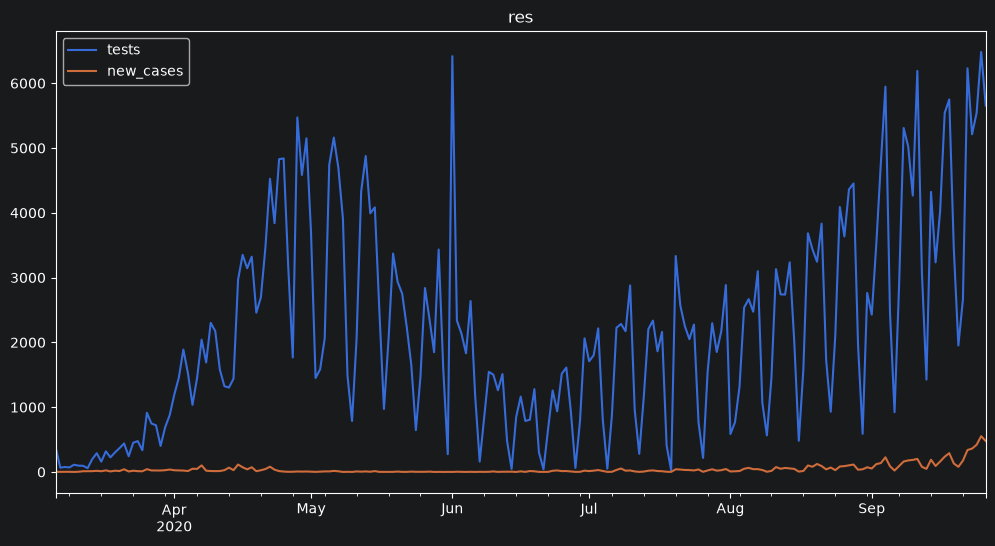

In [17]:
dates = pd.date_range("2020-03-06", "2020-09-26", freq="D")
df = pd.DataFrame({"tests": tests.values, "new_cases": new_cases.values}, index=dates)
df.plot(figsize=(12, 6), title="res")

# More Reading 

### Pandas = Panel Data
Pandas documentation: https://pandas.pydata.org/docs/user_guide/10min.html

### 100-pandas-puzzles
**https://github.com/FIIT-IAU/100-pandas-puzzles** (forked from https://github.com/ajcr/100-pandas-puzzles)